## Теми 3 та 4.Рекурсія та алгоритми сортування

## Завдання 1: Рекурсивне сортування файлів у директорії

### Problem
Правильне застосування структур даних для конкретних завдань

### Approach
Queueing Theory, або Теорія масового обслуговування (ТМО): вартість використання черги Queue зі стандартного модулю queue Python порівняно з
- двосторонньою чергою deque з модуля collections,
- звичайним списком
Для коректності порівняння структури даних поміщено в однакове стохастичне середовище M/M/1, яке відповідає вимозі завдання "постійний потік заявок та їх обробка" - в даному випадку на кожному кроці:
- генерація: Narrivals∼Pois(λ) 
- обслуговування: Nservice∼Pois(μ)

### Implementation
2 основні функції: 
- generate_request(): генерує нові заявки та додає їх до черги 
- process_request(): обробляє заявки, видаляючи їх із черги. 
Головний цикл програми виконує ці функції, імітуючи постійний потік нових заявок та їх обробку.

In [2]:
import os
import shutil
import argparse


# 1. РЕКУРСИВНИЙ ОБХІД ТА КОПІЮВАННЯ

def process_directory(src_dir: str, dst_dir: str):

    print(f"\n📂 {src_dir}")
  
    try:
        items = os.listdir(src_dir)
    except (FileNotFoundError, PermissionError) as e:
        print(f"⚠️ Помилка доступу до {src_dir}: {e}")
        return
    
    for item in items:
        item_path = os.path.join(src_dir, item)

        # якщо це директорія — рекурсія
        if os.path.isdir(item_path):
            process_directory(item_path, dst_dir)

        # якщо це файл — копіюємо
        elif os.path.isfile(item_path):

            _, ext = os.path.splitext(item)
            ext = ext[1:].lower() if ext else "no_extension"

            ext_dir = os.path.join(dst_dir, ext)
            os.makedirs(ext_dir, exist_ok=True)

            dest_path = os.path.join(ext_dir, item)

            counter = 1
            base, extension = os.path.splitext(item)

            while os.path.exists(dest_path):
                dest_path = os.path.join(ext_dir, f"{base}_{counter}{extension}")
                counter += 1

            try:
                shutil.copy2(item_path, dest_path)
            except (PermissionError, FileNotFoundError, OSError) as e:
                print(f"⚠️ Помилка копіювання {item_path}: {e}")

            print(f"✔ {item} → {ext}/")

# 2. СТВОРЕННЯ ТЕСТОВОЇ СТРУКТУРИ

def create_test_structure(base="test_data"):

    structure = {
        "docs": ["a.txt", "b.pdf"],
        "images": ["img1.jpg", "img2.png"],
        "misc": ["data.json", "script.py"]
    }

    deep = {
        "nested": {
            "level1": {
                "level2": ["deep1.txt", "deep2.md"]
            }
        }
    }

    for folder, files in structure.items():
        folder_path = os.path.join(base, folder)
        os.makedirs(folder_path, exist_ok=True)
      
        for file in files:
            with open(os.path.join(folder_path, file), "w") as f:
                f.write(file)
         
    for l1, l2_dict in deep.items():
        for l2, l3_dict in l2_dict.items():
            for l3, files in l3_dict.items():

                folder_path = os.path.join(base, l1, l2, l3)
                os.makedirs(folder_path, exist_ok=True)
        
                for file in files:
                    with open(os.path.join(folder_path, file), "w") as f:
                        f.write(file)
                
    folders_count = sum(len(dirs) for _, dirs, _ in os.walk(base))
    files_count = sum(len(files) for _, _, files in os.walk(base))

    print(
        f"✔ Створено тестову структуру"
        f"({folders_count} папок, {files_count} файлів):\n"
    )

# 3. ГОРИЗОНТАЛЬНИЙ ВИВІД

def print_tree_horizontal(src_dir: str):

    #print("\n📁 STRUCTURE:")

    for root, dirs, files in os.walk(src_dir):
        level = root.replace(src_dir, "").count(os.sep)
        indent = " → " * level

        print(f"{indent}{os.path.basename(root)}/", end="")

        if files:
            print(" | " + ", ".join(files))
        else:
            print()

# 4. СТАТИСТИКА

def print_stats(dst_dir="dist"):

    stats = {}

    for root, dirs, files in os.walk(dst_dir):
        for file in files:

            file_path = os.path.join(root, file)

            _, ext = os.path.splitext(file)
            ext = ext[1:].lower() if ext else "no_extension"

            size = os.path.getsize(file_path)

            if ext not in stats:
                stats[ext] = {
                    "count": 0,
                    "size": 0,
                    "files": []
                }

            stats[ext]["count"] += 1
            stats[ext]["size"] += size
            stats[ext]["files"].append(file)

    print("\n📂 CONTENT OF SORTED DIRECTORIES:\n")

    for ext, data in sorted(stats.items()):

        print(
            f"{ext.upper()}/ "
            f"(files: {data['count']}, size: {data['size']} bytes)"
        )

        for file in sorted(data["files"]):
            print(f"   📄 {file}")

        print()

    print("📊 SUMMARY STATISTICS:\n")

    total_files = 0
    total_size = 0

    for ext, data in sorted(stats.items()):

        print(
            f"{ext:12} | "
            f"files: {data['count']:2} | "
            f"size: {data['size']:4} bytes"
        )

        total_files += data["count"]
        total_size += data["size"]

    print("\n-------------------------------------------")
    print(
        f"TOTAL        | "
        f"files: {total_files:2} | "
        f"size: {total_size:4} bytes"
    )

# 5. CLI 

parser = argparse.ArgumentParser()
parser.add_argument("--source")
parser.add_argument("--destination", default="dist")

args, unknown = parser.parse_known_args()

if args.source is None:
    source = "test_data"
    destination = "dist"  

else:
    source = args.source
    destination = args.destination


# 6. ЗАПУСК (ДЛЯ NOTEBOOK)

create_test_structure()

if os.path.exists("dist"):
    shutil.rmtree("dist")

print_tree_horizontal("test_data")

# використання рекурсивної функції 
source = args.source or "test_data"
destination = args.destination or "dist"

print("\n📦 TRAVERSING & COPYING:")
process_directory(source, destination)

print_stats("dist")

✔ Створено тестову структуру(7 папок, 13 файлів):

test_data/
 → docs/ | a.txt, b.pdf, file1.txt, file2.pdf, notes.txt
 → images/ | img1.jpg, img2.png
 → misc/ | data.json, script.py
 → nested/
 →  → level1/
 →  →  → level2/ | deep1.txt, deep2.md
 →  → sub/ | deep.txt, deep2.md

📦 TRAVERSING & COPYING:

📂 test_data

📂 test_data\docs
✔ a.txt → txt/
✔ b.pdf → pdf/
✔ file1.txt → txt/
✔ file2.pdf → pdf/
✔ notes.txt → txt/

📂 test_data\images
✔ img1.jpg → jpg/
✔ img2.png → png/

📂 test_data\misc
✔ data.json → json/
✔ script.py → py/

📂 test_data\nested

📂 test_data\nested\level1

📂 test_data\nested\level1\level2
✔ deep1.txt → txt/
✔ deep2.md → md/

📂 test_data\nested\sub
✔ deep.txt → txt/
✔ deep2.md → md/

📂 CONTENT OF SORTED DIRECTORIES:

JPG/ (files: 1, size: 8 bytes)
   📄 img1.jpg

JSON/ (files: 1, size: 9 bytes)
   📄 data.json

MD/ (files: 2, size: 35 bytes)
   📄 deep2.md
   📄 deep2_1.md

PDF/ (files: 2, size: 33 bytes)
   📄 b.pdf
   📄 file2.pdf

PNG/ (files: 1, size: 8 bytes)
   📄 img2

### Output / Interpretation

У роботі реалізовано рекурсивний алгоритм обходу файлової системи з копіюванням файлів у структуру директорій, організовану за типами розширень. Запропонований підхід дозволяє ефективно розділяти файли за категоріями та зберігати їхню цілісність під час копіювання.

Додатково реалізовано механізм збору статистики, що включає підрахунок кількості файлів, їхнього обсягу та групування за типами. Це дозволяє аналізувати структуру даних після обробки.

Отримані результати демонструють коректність рекурсивного обходу директорій та стабільність роботи алгоритму.

## Особливості реалізації (Jupyter Notebook / CLI):

- для сумісності з Jupyter Notebook використано argparse.parse_known_args(), що дозволяє ігнорувати системні аргументи IPython (ipykernel_launcher) і уникати помилок виконання
- реалізовано fallback-логіку параметрів: у разі відсутності CLI-аргументів використовуються значення за замовчуванням (test_data, dist)
- код підтримує два режими запуску: notebook-режим (ручне виконання ячеєк) та CLI-режим (через термінал з аргументами виду: python script.py --source ... --destination ...) - виконання Python-файла як скрипта интерпретатором Python 
- логіка виконання відокремлена від парсингу аргументів, що забезпечує гнучкість запуску в різних середовищах


## Task 2: Фрактал «Сніжинка Коха» (за допомогою рекурсії)

### Problem
візуалізація фракталу «Сніжинка Коха»

### Approach
рекурсія


### Implementation
1. Візуалізувати фрактал «Сніжинка Коха». 
2. Користувач має можливість вказати рівень рекурсії.


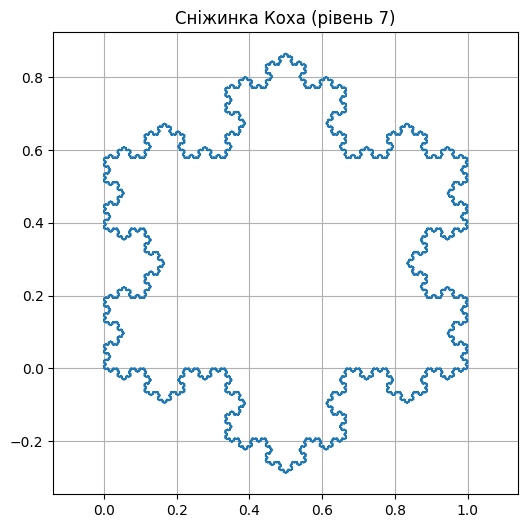


--- Параметри фракталу ---
Розмірність фракталу: 1.26
Рівень рекурсії: 7
Кількість сегментів: 49152
Довжина одного сегменту: 0.000457


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Рекурсивно будуємо один відрізок кривої Коха:

def koch_segment(p1, p2, level):
  
    # базовий випадок: малюємо звичайний прямой відрізок:  
    if level == 0:
        return [p1, p2]

    p1 = np.array(p1)
    p2 = np.array(p2)

    # ділимо відрізок на 3 частини:
    a = p1 + (p2 - p1) / 3
    b = p1 + 2 * (p2 - p1) / 3

    # вектор середньої частини:
    v = b - a

    # будуємо нормаль:
    normal = np.array([v[1], -v[0]])
    norm = np.linalg.norm(normal)
    if norm != 0:
        normal = normal / norm

    # висота рівностороннього трикутника:
    peak = (a + b) / 2 + normal * np.linalg.norm(v) * np.sqrt(3) / 2

    # рекурсивно обробляємо 4 підвідрізки:
    left = koch_segment(p1, a, level - 1)
    mid1 = koch_segment(a, peak, level - 1)
    mid2 = koch_segment(peak, b, level - 1)
    right = koch_segment(b, p2, level - 1)

    # об’єднуємо результат без дублювання точок:
    return left[:-1] + mid1[:-1] + mid2[:-1] + right[:-1] + [p2]

# Будуємо сніжинку Коха з рівностороннього трикутника:

def build_snowflake(level):

    # вершини початкового трикутника:
    p1 = (0, 0)
    p2 = (1, 0)
    p3 = (0.5, np.sqrt(3) / 2)

    # три сторони:
    side1 = koch_segment(p1, p2, level)
    side2 = koch_segment(p2, p3, level)
    side3 = koch_segment(p3, p1, level)

    # об’єднання всіх точок:
    points = side1 + side2 + side3

    x, y = zip(*points)

    # візуалізація:
    plt.figure(figsize=(6, 6))
    plt.plot(x, y, linewidth=1)
    plt.axis("equal")
    plt.grid(True)
    plt.title(f"Сніжинка Коха (рівень {level})")
    plt.show()

# Ввод користувачем рівня рекурсії:

def get_level():

    while True:

        try:             
            level = int(input("Введіть рівень рекурсії (0-8): "))

            if level < 0:
                print("Помилка: рівень рекурсії не може бути від'ємним.")
                continue

            if level > 8:
                print("Помилка: занадто великий рівень рекурсії.")
                print("Рекомендується значення від 0 до 8.")
                continue

            return level

        except ValueError:
            print("Помилка: введіть ціле число.")

# запуск програми:

def main():

    level = get_level()
    build_snowflake(level)

    # Кількість сегментів після n ітерацій:
    segments = 3 * (4 ** level)

    # Довжина одного сегменту
    segment_length = 1 / (3 ** level)

    D = np.log(4) / np.log(3)

    print("\n--- Параметри фракталу ---")
    print(f"Розмірність фракталу: {D:.2f}")
    print(f"Рівень рекурсії: {level}")
    print(f"Кількість сегментів: {segments}")
    print(f"Довжина одного сегменту: {segment_length:.6f}")

if __name__ == "__main__":
    main()


### Output / Interpretation

Рекурсивна функція реалізує принцип самоподібності фрактала Коха, коли рівень рекурсії для візуалізації обираєє користувач.

## Рекомендація
Для запобігання переповненню стека в програмі введено обмеження максимально допустимого рівня рекурсії. Через експоненційне зростання кількості сегментів та часу побудови значення більше 8–10 вважаються недоцільними. Це обмеження забезпечує стабільну роботу програми та запобігає надмірному використанню ресурсів.


## Завдання 3: Порівняння трьох алгоритмів сортування

### Problem
1. Підтвердження емпіричними даними теоретичних оцінок складності алгоритмів  сортування: злиттям, вставками та Timsort за часом виконання, отримание шляхом тестування цих алгоритмів на різних наборах даних. 
2. Демонстрація, що поєднання сортування злиттям і сортування вставками робить алгоритм Timsort набагато ефективнішим в більшості випадків, і саме тому використовують дві вбудовані у Python функції сортування: sorted() і sort().
3. Ооформлення висновків у вигляді файлу readme.md до домашнього завдання.

### Approach
Теорія алгоритмів: алгоритми сортування Insertion Sort, Merge Sort і Timsort ( вбудовані у Python функції сортування: sorted() і sort()).

Фактори, що впливають на ефективність сортування:
- розмір вхідних даних (по кількості едементів). Алгоритми з гарною асимптотикою можуть програвати на малих даних через накладні витрати, тому Insertion Sort може вигравати на невеликих масивах, незважаючи на O(n**2)
- ступінь впорядкованості даних (в ширшому погляді, адаптивність): рівень початкової відсортованості, назад-відсортованості, випадковості, складання з кількох відсортованих блоків (runs)
- характер розподілу значень: велика кількість однакових елементів
- вимога гарантованої продуктивності: направленість  системи на середній/найгіриший/найкращий випадок
- вимога по обмеженню пам'яті. Алгоритми Merge Sort і Timsort використовують додаткову пам'ять: теоретично O(n) чии до цієї оцінки
- тип даних: порівняння об'єктів може бути значно дорожчим за порівняння чисел. Але в Python все є об'єктом - різниця може бути в типу даних mutable/immutable (тому існують дві реалізації Timsort: sorted() и sort())

### Implementation
Порівняти ефективность алгоритмів сортування  Insertion Sort, Merge Sort і Timsort (використати вбудовані функції сортування: sorted() і sort()) залежно від розміру набору даних, ступеня їх упорядкованості та характеру розподілу значень. 
Оцінити за показниками часової та просторової складності, а також стійкості алгоритмів до несприятливих вхідних даних.
Для порівняння використати основну структур даних list, коли тип елементів int зі зміною розміру даних та ступеня впорядкованості. Додатково розглядається тип елементу: користувацький об'єкт, коли порівняння стає більш коштовним.

*Примітка: для big data алгоритм сортування Insertion Sort не використовується (складність: O(n^2)) - його виконання може зайняти декілька десятків хвилин. Він локальний, тому його не вийде масштабувати, як наприклад External MergeSort (розділити на незалежні блоки з файловими runї) -  Insertion Sort працює завжди як єдиний процес

n	    що працює ("чисті" алгоритми)
100	    всі 3 алгоритми
1000	всі 3 алгоритми
10000	Merge + Timsort (Insertion може мати занадто багато операцій - має бути різке зростання часу вже на середніх даних)

In [370]:
# I. Імпорт модулів

import random
import timeit
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tracemalloc

In [371]:
# II. Алгоритмb сортування
# IIa. Алгоритм сортування вставками (Insertion Sort)

def insertion_sort(arr):

    # Створюємо копію, щоб не змінювати вихідний список
    arr = arr.copy()

    for i in range(1, len(arr)):

        key = arr[i]
        j = i - 1

        while j >= 0 and arr[j] > key:
            arr[j + 1] = arr[j]
            j -= 1

        arr[j + 1] = key

    return arr

In [372]:
# IIb. Алгоритм сортування злиттям (Merge Sort)

def merge_sort(arr):

    if len(arr) <= 1:
        return arr

    middle = len(arr) // 2

    left = merge_sort(arr[:middle])
    right = merge_sort(arr[middle:])

    return merge(left, right)


# Функція злиття двох відсортованих частин

def merge(left, right):

    result = []

    i = 0
    j = 0

    while i < len(left) and j < len(right):

        if left[i] <= right[j]:
            result.append(left[i])
            i += 1

        else:
            result.append(right[j])
            j += 1

    result.extend(left[i:])
    result.extend(right[j:])

    return result

In [373]:
# IIc. Timsort через вбудований метод sort()

def timsort(arr):

    arr = arr.copy()
    arr.sort()

    return arr

In [374]:
# III. Генератори даних
# IIIa. Генерація відсортованого списку

def generate_sorted(n):

    return list(range(n))

In [375]:
# IIIb. Генерація списку у зворотному порядку

def generate_reverse(n):

    return list(range(n, 0, -1))

In [376]:
# IIIc.Генерація випадкового списку

def generate_random(n):

    return random.sample(range(n * 10), n)

In [377]:
# IIId. Генерація майже відсортованого списку

def generate_almost_sorted(n, swaps=5):

    arr = list(range(n))

    for _ in range(swaps):

        i = random.randint(0, n - 1)
        j = random.randint(0, n - 1)

        arr[i], arr[j] = arr[j], arr[i]

    return arr

In [378]:
# IIIt. Генерація масиву з природними "runs" (відсортовані блоки)

def generate_runs(n, max_run_size=50):

    arr = []
    current = 0

    while current < n:

        # випадковий розмір блоку
        run_size = random.randint(10, max_run_size)

        # щоб не вийти за межі
        run_size = min(run_size, n - current)

        # створюємо відсортований блок
        run = list(range(current, current + run_size))

        arr.extend(run)

        current += run_size

    # перемішуємо порядок блоків (але не всередині них)
    runs = []

    # розбиваємо назад на блоки
    i = 0
    while i < len(arr):

        size = random.randint(10, max_run_size)
        runs.append(arr[i:i + size])
        i += size

    random.shuffle(runs)

    # об’єднуємо назад
    result = []

    for r in runs:
        result.extend(r)

    return result

In [379]:
# IV. Вимірювання часу виконання алгоритму (imeit.timeit())

def measure_time(sort_function, data, repeats=3):

    # Створюємо функцію без параметрів для timeit
    execution_time = timeit.timeit(
        lambda: sort_function(data),
        number=repeats
    )

    # Середній час одного запуску
    return execution_time / repeats

In [380]:
# V. Проведення експерименту для заданого розміру масиву - перевірка для Insertion Sort: big data

def run_experiment(n):

    datasets = {
        "Sorted": generate_sorted(n),
        "Almost Sorted": generate_almost_sorted(n),
        "Random": generate_random(n),
        "Reverse": generate_reverse(n),
        "Runs": generate_runs(n)
    }

    algorithms = {
        "Insertion Sort": insertion_sort,
        "Merge Sort": merge_sort,
        "Timsort": timsort
    }

    # Сценарії, які дозволено тестувати для великих масивів Insertion Sort:
    allowed_large_cases = {
        "Sorted",
        "Almost Sorted"
    }

    results = {}

    for algorithm_name, algorithm in algorithms.items():

        results[algorithm_name] = {}

        for dataset_name, dataset in datasets.items():

            # Обмеження для Insertion Sort на великих даних
            if (
                algorithm_name == "Insertion Sort"
                and n > 10000
                and dataset_name not in allowed_large_cases
            ):
                results[algorithm_name][dataset_name] = None
                continue

            time_value = measure_time(
                algorithm,
                dataset
            )

            results[algorithm_name][dataset_name] = time_value

    return results

In [381]:
# VI. Перетворення в датафрейм

def build_dataframe(all_results):

    rows = []

    for n, result_n in all_results.items():

        for algo, algo_data in result_n.items():

            for scenario, time_value in algo_data.items():

                rows.append({
                    "Size": n,
                    "Algorithm": algo,
                    "Scenario": scenario,
                    "Time": time_value
                })

    return pd.DataFrame(rows)

In [382]:
# VII. Візуалізація результатів експерименту
# VIIa. Візуалізація по сценаріях

def plot_by_scenario(df, scenario):

    plt.figure(figsize=(10, 6))

    # фільтруємо дані по сценарію
    data = df[df["Scenario"] == scenario]

    for algorithm in data["Algorithm"].unique():

        subset = data[data["Algorithm"] == algorithm]

        # сортуємо по розміру (важливо для лінійного графіка)
        subset = subset.sort_values("Size")

        plt.plot(
            subset["Size"],
            subset["Time"],
            marker="o",
            label=algorithm
        )

    plt.title(f"II. Порівняння алгоритмів: {scenario} data")
    plt.xlabel("Розмір даних (n)")
    plt.ylabel("Час виконання (сек)")

    plt.xscale("log")   # важливо для експоненційних ростів
    plt.yscale("log")

    plt.grid(True)
    plt.legend()

    plt.show()

In [383]:
# VIIb.Функція аналізу одного алгоритму

def plot_by_algorithm(df, algorithm_name):

    plt.figure(figsize=(10, 6))

    data = df[df["Algorithm"] == algorithm_name]

    for scenario in data["Scenario"].unique():

        subset = data[data["Scenario"] == scenario]

        subset = subset.sort_values("Size")

        plt.plot(
            subset["Size"],
            subset["Time"],
            marker="o",
            label=scenario
        )

    plt.title(f"III. Поведінка алгоритма {algorithm_name}")
    plt.xlabel("Розмір даних (n)")
    plt.ylabel("Час виконання (сек)")

    plt.xscale("log")
    plt.yscale("log")

    plt.grid(True)
    plt.legend()

    plt.show()

In [384]:
# VIIc. Функція запуску всієї візуалізації

def run_visualization(df):

    scenarios = ["Sorted", "Almost Sorted", "Random", "Reverse", "Runs"]

    algorithms = ["Insertion Sort", "Merge Sort", "Timsort"]

    # графіки по сценаріях
    for scenario in scenarios:
        plot_by_scenario(df, scenario)

    # графіки по алгоритмах
    for algorithm in algorithms:
        plot_by_algorithm(df, algorithm)


In [385]:
# Memory Function

def measure_memory(func, data):


    tracemalloc.start()
    func(data)

    _, peak = tracemalloc.get_traced_memory()

    tracemalloc.stop()

    return peak 

In [386]:
def main():

    sizes = [100, 1000, 100000]

    all_results = {}

    for n in sizes:

        print(f"Запуск експерименту для n = {n}")

        all_results[n] = run_experiment(n)

    df = build_dataframe(all_results)

    print("\nЕксперимент завершено.")

    # Optional2:

   
    # Memory^ Data & Calculation

    sizes = [1000, 10000, 50000]

    merge_mem = []
    sort_mem = []
    sorted_mem = []

    for n in sizes:
        data = generate_random(n)

        # Merge Sort
        merge_mem.append(measure_memory(merge_sort, data))

        # Timsort sort()
        data_copy = data.copy()
        sort_mem.append(measure_memory(lambda x: x.sort(), data_copy))

        # Timsort sorted()
        sorted_mem.append(measure_memory(lambda x: sorted(x), data))

    #  Memory Visualization

    plt.figure(figsize=(8,5))

    plt.plot(sizes, merge_mem, marker="o", label="Merge Sort")
    plt.plot(sizes, sort_mem, marker="o", label="Timsort sort()")
    plt.plot(sizes, sorted_mem, marker="o", label="Timsort sorted()")

    plt.xlabel("n")
    plt.ylabel("Peak memory (bytes)")
    plt.title("I. Три стратегії: Ефективність vs Функціональная Безпека vs: Стабільність")

    plt.legend()
    plt.grid(True)

    plt.show()   

    run_visualization(df)


Запуск експерименту для n = 100
Запуск експерименту для n = 1000
Запуск експерименту для n = 100000

Експеримент завершено.


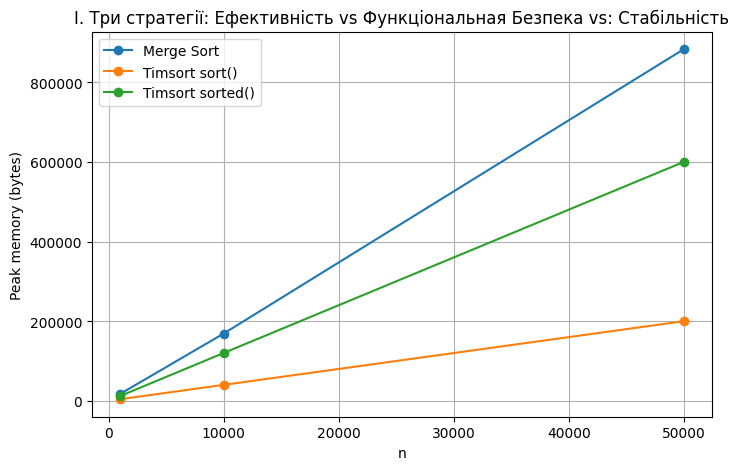

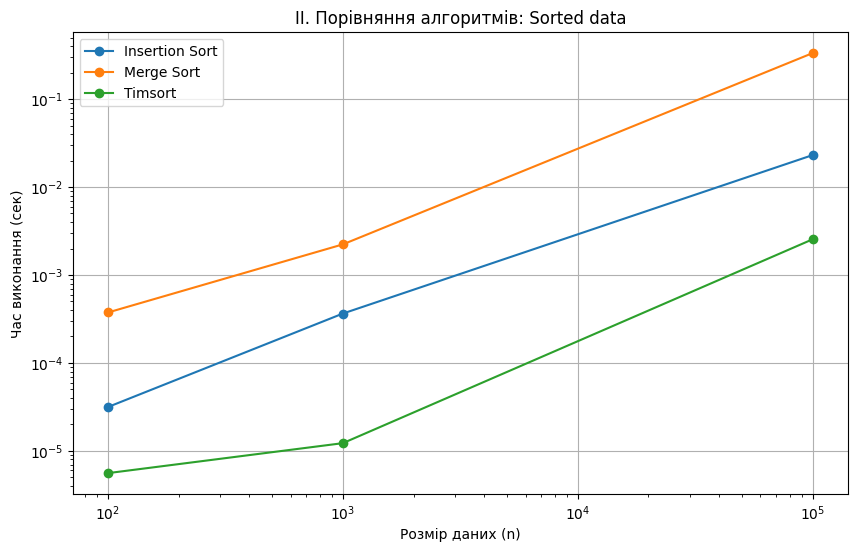

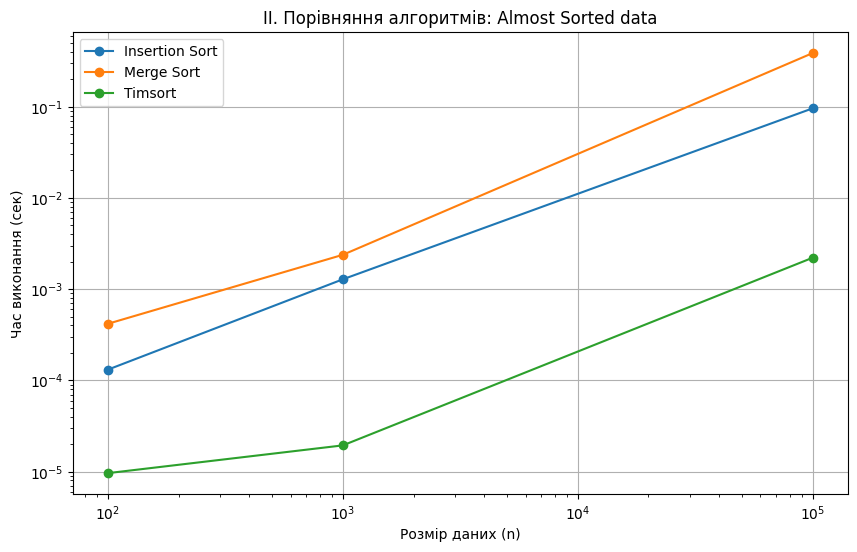

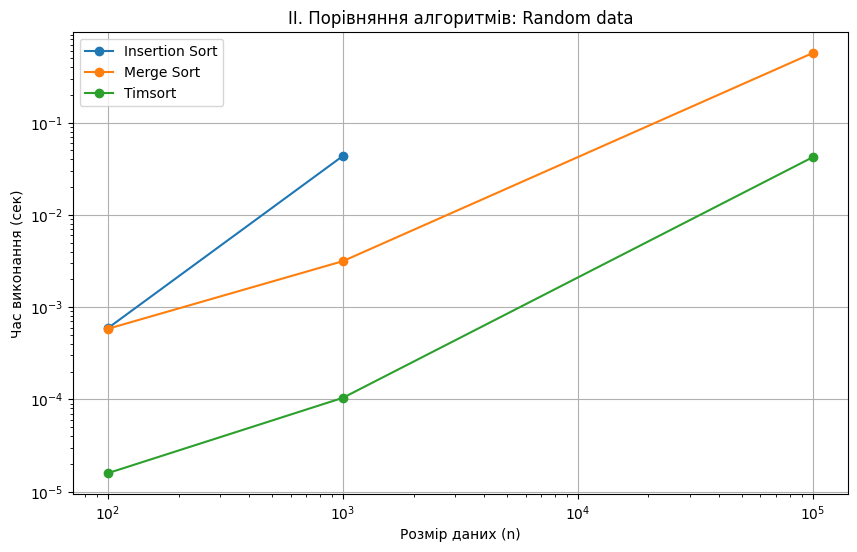

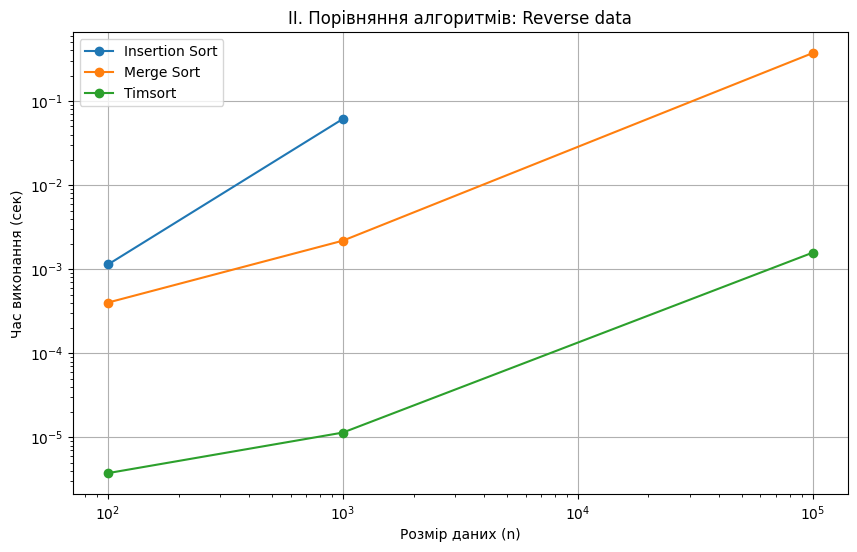

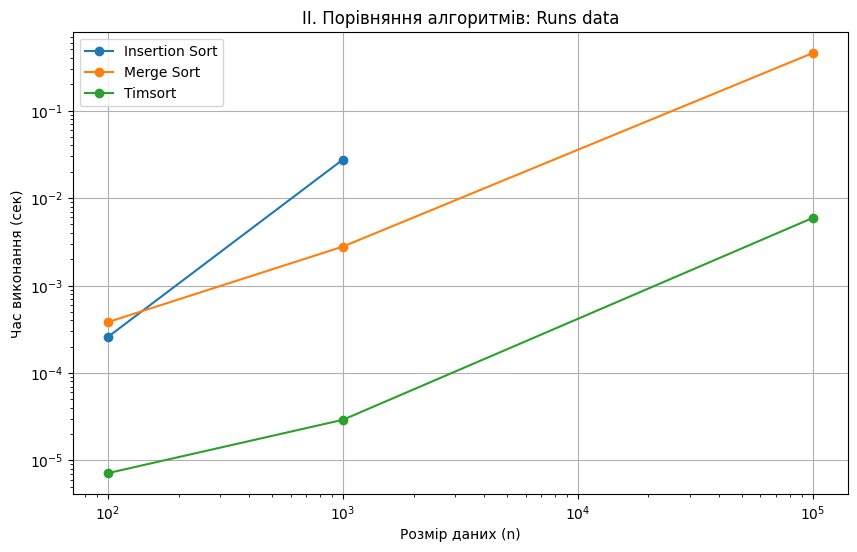

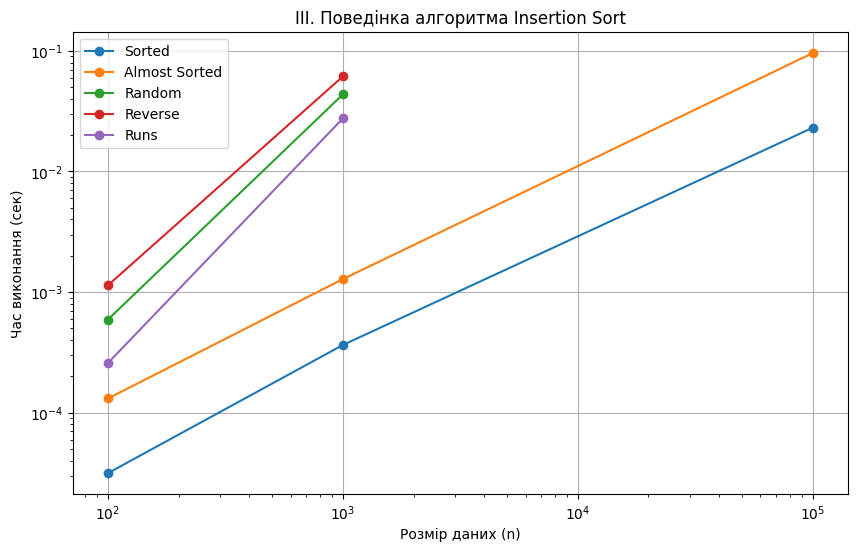

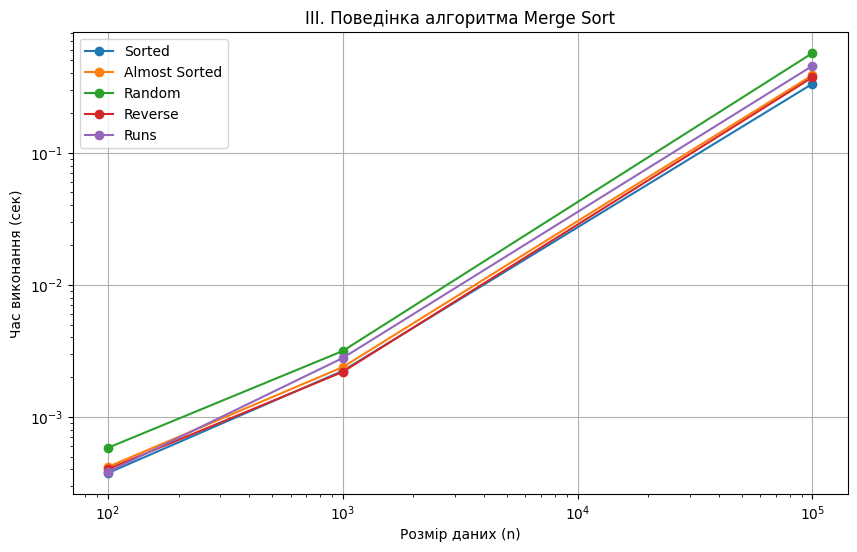

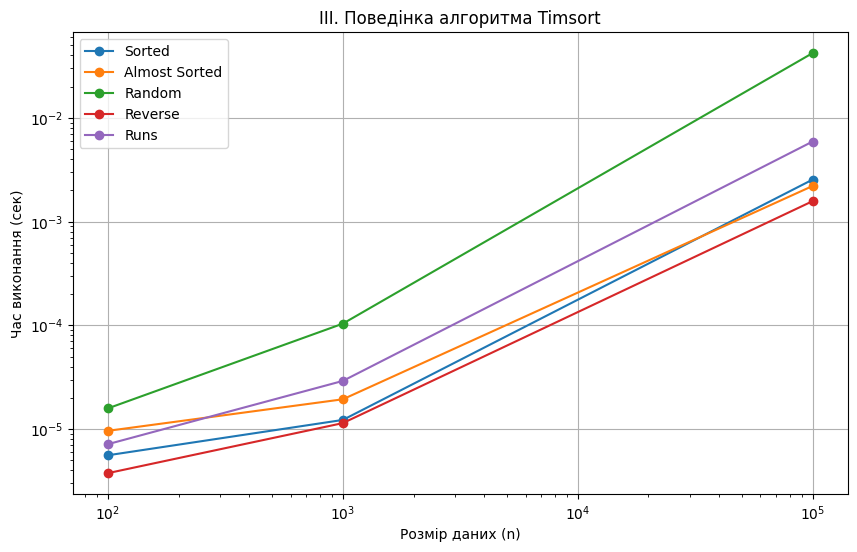

In [387]:
if __name__ == "__main__":
    main()

### Output / Interpretation

Для завдання обрано три алгоритми сортування: Insertion Sort, Merge Sort і Timsort.  Виходячи з теорії алгоритміві розглядаючи їх через призму просторової і часової складності, використання цих алгоритмів зводиться до вибору стратегії.

Результати роботи наведено на трьох графиках: I. Три Стратегії: Ефективність vs Функціональна безпека vs СТабільність. II. Порівняння алгоритмів. III. Поведінка алгоритмів.

I. Три стратегії можна розглядати, як 
- стратегія ефективності, яку представляє алгоритм Timsort  в реалізації вбудованої функції sort(): мінімальна па'ять, in-place модіфікаціф, оптимізація за рахунок runs - результат: добра адаптацыя за рахунок можливоъ мутацыъ даних
- стратегія функцыональної безпеки, яку представляє алгшоритм Timsort  в реалізації вбудованої функції sorted(): той самий алгоритм, але з копіюванням, що заьезпечує погнозованість даних, але за рахунок часу виконання і додаткової пам'яті
- стратегія стабільності: алгоритм Merge Sort, де пам'яьт як ресурс

Отримані на графіку дані співпадають с теоретичними значеннями часової і просторової складності.

II. Порівняння ефективності алгоритмів сортування Insertion Sort, Merge Sort і Timsort відбувалось за п'ятьма сценаріми: 
- вже відсотовані дані - найкращий сценарій
- майже відсортовані дані - майже найкращий сценарій
- випадкові данні - середній сценарій
- реверсні дані - найгірший сценарій
- блочні дані (runs) - спеціальний випадок

Відповідно до розміру даних, експерименти проводилися для списків цілих чисел: 
-  n = 100 - малий розмір
-  n = 1000 - середній розмір
-  n = 100000 - великий розмір

Примітка*. Виходячі, що найгірший і середній сценарії для алгоритма Insertion Sort передбачає квадратичну залежність при виконання операцій (O(n^2)), було зразу вирішено не проводити експеримент для цього алгоритма для найгіршего і середнього сценарієв при даних великого розміру. ПРи спробі зробити сортування за допомогою цього алгоритма для спеціального сценарію (runs) час виконання був  великим, і після 12 хвилин воно було перервано. Тому алгоритм  Insertion Sort при великих даних було перевірено тільки для найкращого і майже найкращого сценарієв.

На графіках "Порівняння алгоритмів сортуванняInsertion Sort, Merge Sort і Timsort для малих, середнього розміру і великих даних беззаперечно перемагає алгоритм Timsort, що свідчить про його велику адаптивність до різних сценарієв, що підтверджує теоретичні оцінки його часової складності не виже O(nlog n). 
Не дивлячись на те, що алгоритм Merge Sort має для всіх випадків співпадаючу часову складність, він ігонрує реальну структуру даних і тому менш ефективний за Timsort.
На всіх графіках при всіх сценаріях добре проглядається інша, квадратична складність алгоритму Insertion Sort, який може мати перевагу тільки на дуже малих даних.

II. На трьох графіках "Поведінка алгоритмів" можна прослідкувати, як стабільно однаково працює при різних сценаріях алгоритм Merge Sort, як і те, що можливо використання алгоритму  Insertion Sort тільки при дуже добрих сценаріях. Для алгоритму Timsort, цілком зпрозуміло, найбільш затратним по часу є сценарій з випадковими даними.
